In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#shared drive folder - add shortcut to my drive
try:
  from google.colab import drive
  drive.mount('/content/drive')
  SHARED_FOLDER = '/content/drive/MyDrive/CS445 Group Project'
except:
  SHARED_FOLDER = './outputs'
  print("Drive not available, saving locally to ./outputs") #for the grader to run locally

MODELS_DIR = os.path.join(SHARED_FOLDER, 'models')
CE_MODEL_DIR = os.path.join(MODELS_DIR, 'cross_encoder')
BE_MODEL_DIR = os.path.join(MODELS_DIR, 'bi_encoder')
PLOTS_DIR = os.path.join(SHARED_FOLDER, 'plots')
RESULTS_DIR = os.path.join(SHARED_FOLDER, 'results')
for d in [MODELS_DIR, CE_MODEL_DIR, BE_MODEL_DIR, PLOTS_DIR, RESULTS_DIR]:
  os.makedirs(d, exist_ok=True)
TRAIN_MODE = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cpu':
  print(f"Change runtime type to T4 GPU")
print(f"Train mode: {TRAIN_MODE}")
print(f"Folder currently has:\n {os.listdir(SHARED_FOLDER)}")

Device: cuda
Train mode: True
Folder currently has:
 ['models', 'plots', 'results', 'results 1.0 - saved aside for now', 'dataset setup.ipynb']


#data loading

In [ ]:
!git version

git version 2.34.1


In [ ]:
!git clone https://github.com/Janosch-Gehring/semeval26-05-scripts.git
%cd semeval26-05-scripts/data/

Cloning into 'semeval26-05-scripts'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 51 (delta 7), reused 4 (delta 4), pack-reused 36 (from 1)
Receiving objects: 100% (51/51), 268.49 KiB | 5.16 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/semeval26-05-scripts/data


In [ ]:
with open('train.json', 'r') as f:
    train_df = pd.DataFrame(json.load(f)).T #transpose to get rows instead of columns
with open('dev.json', 'r') as f:
    dev_df = pd.DataFrame(json.load(f)).T

print(f"Dataset split (Train/Validation): {len(train_df)}/{len(dev_df)}")
print("Train set shape:", train_df.shape)
print("Validation set shape:", dev_df.shape)
print("Columns:",train_df.columns.tolist())

Dataset split (Train/Validation): 2280/588
Train set shape: (2280, 11)
Validation set shape: (588, 11)
Columns: ['homonym', 'judged_meaning', 'precontext', 'sentence', 'ending', 'choices', 'average', 'stdev', 'nonsensical', 'sample_id', 'example_sentence']


#Exploratory Dataset Analysis
Our target label will be "average" based on the columns in the train & validation sets.
- "average" = mean of human ratings (to be predicted).
- "stdev" = std deviation of human ratings.

1. Rating (average) Distribution Plot
2. Homonym Uniqueness
3. Text Length Analysis

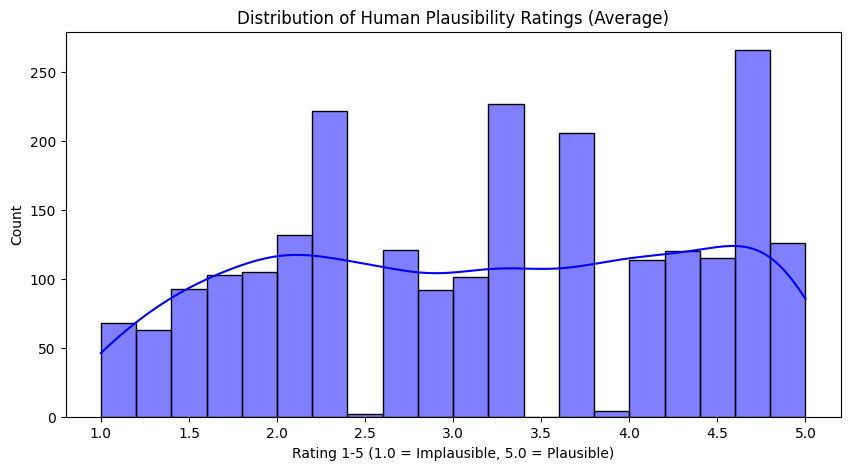

Unique Homonyms: 220
Average story length is 50.0 words


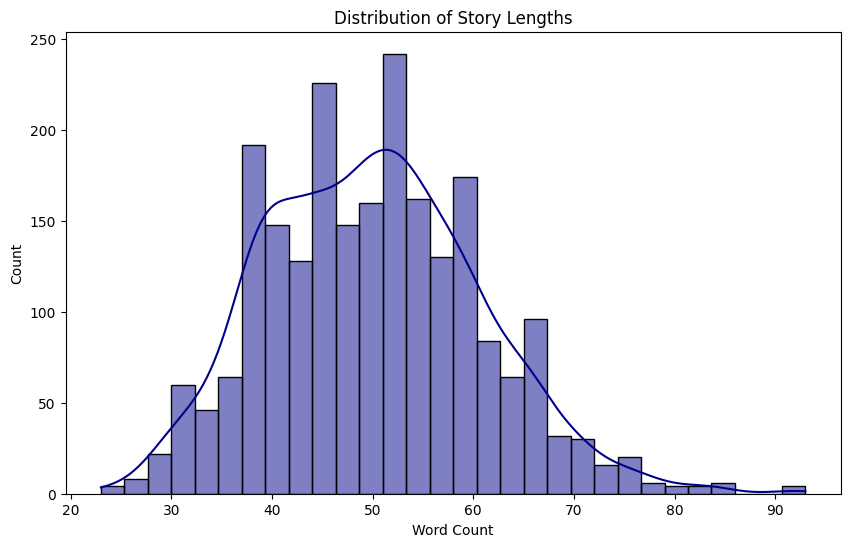

In [ ]:
#eda

#rating (average) distribution plot - distribution of the value we want to predict across the dataset
plt.figure(figsize=(10, 5))
sns.histplot(train_df['average'], bins=20, kde=True, color='blue')
plt.title('Distribution of Human Plausibility Ratings (Average)')
plt.xlabel('Rating 1-5 (1.0 = Implausible, 5.0 = Plausible)')
plt.ylabel('Count')
plt.savefig('rating_distribution.png')
plt.show()

#homonym uniqueness -
uniqueHomonym = train_df['homonym'].nunique()
print(f"Unique Homonyms: {uniqueHomonym}")

#text length analysis - mean of how long the stories are
train_df['text'] = train_df['precontext'] + " " + train_df['sentence'] + " " + train_df['ending'] #text = precontext + sentence + ending considered altogether at once.
train_df['wordCount'] = train_df['text'].str.split().str.len() #count words in text
print(f"Average story length is {train_df['wordCount'].mean():.1f} words") #avg length of text / sentence
plt.figure(figsize=(10, 6))
sns.histplot(train_df['wordCount'], kde=True, color='darkblue', bins=30)
plt.title('Distribution of Story Lengths')
plt.xlabel('Word Count')
plt.ylabel('Count')
plt.savefig('text_length_distribution.png')
plt.show()

# Cross Encoder - GlossBERT
- In this implementation, we paired encode story and candidate sense gloss together as a sentence pair: `[CLS] story [SEP] gloss [SEP]`. This section is based on GlossBERT (Huang et al., 2019). Regression head predicts sentence plausability score on CLS token.

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error

In [ ]:
with open("train.json", "r") as f:
    train_df = pd.DataFrame(json.load(f)).T

with open("dev.json", "r") as f:
    dev_df = pd.DataFrame(json.load(f)).T

with open("test.json", "r") as f:
    test_df = pd.DataFrame(json.load(f)).T

for df in [train_df, dev_df, test_df]:
    df['average'] = pd.to_numeric(df['average'], errors='coerce')
    df['stdev'] = pd.to_numeric(df['stdev'], errors='coerce')

In [ ]:
print(train_df.shape)
print(dev_df.shape)
print(test_df.shape)

(2280, 11)
(588, 11)
(930, 11)


In [ ]:
train_df["story"] = (
    train_df["precontext"] + " " +
    train_df["sentence"] + " " +
    train_df["ending"]
)

dev_df["story"] = (
    dev_df["precontext"] + " " +
    dev_df["sentence"] + " " +
    dev_df["ending"]
)

test_df["story"] = (
    test_df["precontext"] + " " +
    test_df["sentence"] + " " +
    test_df["ending"]
)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
example = tokenizer(
    train_df["story"].iloc[0],
    train_df["judged_meaning"].iloc[0],
    truncation=True,
    padding="max_length",
    max_length=256
)

In [ ]:
print(example.keys())

KeysView({'input_ids': [101, 1996, 2214, 3698, 26747, 1999, 1996, 3420, 1997, 1996, 8395, 1012, 10254, 8920, 2049, 12727, 13764, 2015, 2007, 1037, 20555, 8306, 1012, 2016, 4999, 2065, 2009, 2071, 2022, 2716, 2067, 2000, 2166, 1012, 1996, 4022, 2481, 1005, 1056, 2022, 7594, 1012, 2016, 5067, 1037, 6046, 8068, 1998, 2246, 2006, 17300, 2135, 1010, 5627, 2070, 2166, 2067, 2046, 1996, 2214, 3698, 1012, 102, 1996, 4489, 1999, 5992, 3715, 2090, 2048, 2685, 1999, 1037, 4984, 5228, 1999, 5285, 3215, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
def tokenize_function(example):
    enriched_gloss = [
        m + " For example: " + e
        for m, e in zip(example["judged_meaning"], example["example_sentence"])
    ]
    return tokenizer(
        example["story"],
        enriched_gloss,
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
dev_dataset = Dataset.from_pandas(dev_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("average", "labels")
dev_dataset = dev_dataset.rename_column("average", "labels")
test_dataset = test_dataset.rename_column("average", "labels")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])
dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "token_type_ids", "labels"])

print(f"Train: {len(train_dataset)}, Dev: {len(dev_dataset)}, Test: {len(test_dataset)}")

Map:   0%|          | 0/2280 [00:00<?, ? examples/s]

Map:   0%|          | 0/588 [00:00<?, ? examples/s]

Map:   0%|          | 0/930 [00:00<?, ? examples/s]

Train: 2280, Dev: 588, Test: 930


In [ ]:
#evaluation metrics

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.flatten()
    spearman = spearmanr(labels, predictions).correlation
    mse = mean_squared_error(labels, predictions)
    return {
        "spearman": spearman,
        "mse": mse
    }

#accuracy at std deviation
def accuracy_at_std(predictions, gold_ratings, gold_stdevs):
  correct = np.abs(predictions - gold_ratings) <= gold_stdevs
  return correct.mean()

train & load cross encoder

In [ ]:
from transformers import AutoModelForSequenceClassification

#Training mode - the model needs to be trained only once, we will save it into shared drive folder and after the single training run it can be loaded.
if TRAIN_MODE:
  model = AutoModelForSequenceClassification.from_pretrained(
      "bert-base-uncased",
      num_labels=1,
      problem_type="regression"
  )
  training_args = TrainingArguments(
      output_dir="./checkpoints_ce",
      eval_strategy="epoch",
      save_strategy="epoch",
      num_train_epochs=8,
      per_device_train_batch_size=16,
      per_device_eval_batch_size=16,
      learning_rate=2e-5,
      weight_decay=0.01,
      warmup_steps=72,
      load_best_model_at_end=True,
      metric_for_best_model="spearman",
      greater_is_better=True,
      logging_steps=50,
      seed=42,
      fp16=torch.cuda.is_available(),
  )
  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=dev_dataset,
      compute_metrics=compute_metrics
  )

  #train model
  trainer.train()
  trainer.save_model(CE_MODEL_DIR)
  tokenizer.save_pretrained(CE_MODEL_DIR)
  print(f"Cross-encoder saved to {CE_MODEL_DIR}")

#Training mode = false -> load CE model instead of retraining
else:
  model = AutoModelForSequenceClassification.from_pretrained(
      CE_MODEL_DIR,
      num_labels=1,
      problem_type="regression"
  )
  tokenizer = AutoTokenizer.from_pretrained(CE_MODEL_DIR)
  training_args = TrainingArguments(
      output_dir='./tmp_ce',
      per_device_eval_batch_size=16,
      fp16=torch.cuda.is_available(),
  )
  trainer = Trainer(
      model=model,
      args=training_args,
      compute_metrics=compute_metrics
  )
  print(f"Cross encoder loaded from {CE_MODEL_DIR}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Spearman,Mse
1,2.526674,1.398104,0.149465,1.398104
2,1.193913,1.292395,0.338061,1.292395
3,0.840165,1.276645,0.374953,1.276645
4,0.625772,1.293317,0.399737,1.293317
5,0.494140,1.364270,0.400254,1.364270
6,0.376138,1.382686,0.417382,1.382686
7,0.317667,1.377625,0.434969,1.377625
8,0.234394,1.351272,0.437377,1.351272


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Cross-encoder saved to /content/drive/MyDrive/CS445 Group Project/models/cross_encoder


In [ ]:
ce_preds_output = trainer.predict(dev_dataset)
ce_preds = np.clip(ce_preds_output.predictions.flatten(), 1.0, 5.0)
ce_gold = dev_df['average'].values
ce_gold_std = dev_df['stdev'].values

ce_spearman = spearmanr(ce_gold, ce_preds).correlation
ce_acc_std = accuracy_at_std(ce_preds, ce_gold, ce_gold_std)
ce_mse = mean_squared_error(ce_gold, ce_preds)

print("Cross encoder results")
print(f"Spearman Correlation: {ce_spearman:.4f}")
print(f"Accuracy@std: {ce_acc_std:.4f}")
print(f"MSE: {ce_mse:.4f}")

Cross encoder results
Spearman Correlation: 0.4374
Accuracy@std: 0.5680
MSE: 1.3506


In [ ]:
for i in range(5):
    print("Story:")
    print(dev_df["story"].iloc[i])

    print("\nGloss:")
    print(dev_df["judged_meaning"].iloc[i])

    print("\nGold:", ce_gold[i])
    print("Prediction:", ce_preds[i])

    print("\n" + "="*80 + "\n")

Story:
The detectives arrived at the abandoned train station. They were looking for signs of the missing artifact. A faint trail caught their attention. They followed the track. They began to run along the abandoned railway line, hopping from wooden sleeper to sleeper to avoid twisting an ankle.

Gloss:
a pair of parallel rails providing a runway for wheels

Gold: 3.6
Prediction: 4.1054688


Story:
The detectives arrived at the abandoned train station. They were looking for signs of the missing artifact. A faint trail caught their attention. They followed the track. They began to run along the abandoned railway line, hopping from wooden sleeper to sleeper to avoid twisting an ankle.

Gloss:
evidence pointing to a possible solution

Gold: 3.6
Prediction: 3.6347656


Story:
The detectives arrived at the abandoned train station. They were looking for signs of the missing artifact. A faint trail caught their attention. They followed the track. They found interesting clues that helped them 

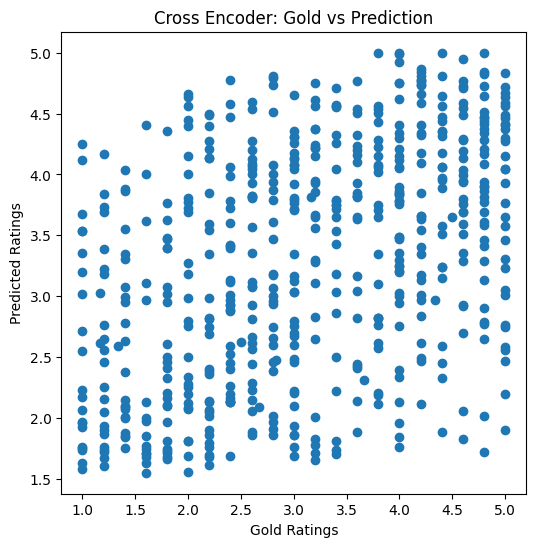

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(ce_gold, ce_preds)
plt.xlabel("Gold Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Cross Encoder: Gold vs Prediction")
plt.savefig(os.path.join(PLOTS_DIR, "ce_gold_vs_prediction.png"))
plt.show()

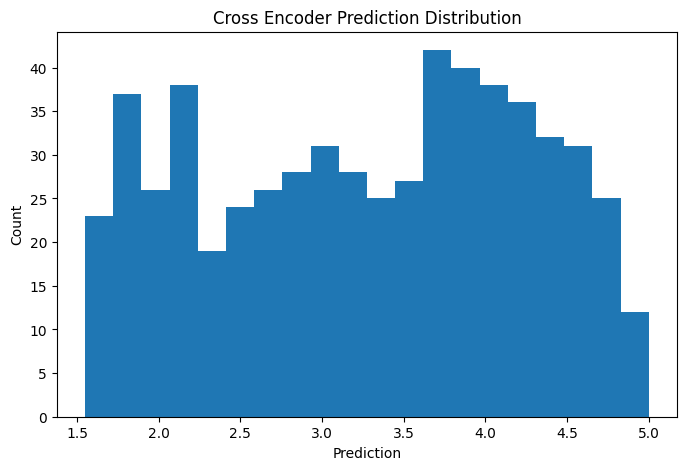

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(ce_preds, bins=20)
plt.title("Cross Encoder Prediction Distribution")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.savefig(os.path.join(PLOTS_DIR, "ce_prediction_distribution.png"))
plt.show()

In [ ]:
errors = np.abs(ce_gold - ce_preds)

worst_idx = np.argsort(errors)[-10:]

In [ ]:
for idx in worst_idx:

    print("Story:")
    print(dev_df["story"].iloc[idx])

    print("\nGloss:")
    print(dev_df["judged_meaning"].iloc[idx])

    print("\nGold:", ce_gold[idx])
    print("Prediction:", ce_preds[idx])

    print("\nError:", errors[idx])

    print("\n" + "="*80 + "\n")

Story:
James sat quietly at the bar, listening to the murmur of conversations around him. He had been coming here every evening since arriving in town, hoping to learn something valuable. The regulars were friendly enough and sometimes shared interesting pieces of information. There were some decent tips to be taken advantage of. 

Gloss:
a relatively small amount of money given for services rendered (as by a waiter)

Gold: 1.0
Prediction: 3.6738281

Error: 2.673828125


Story:
Emma glanced at her phone, checking the time. The evening plans were about to start, and she felt pressure from her friends. They were all eager to see what the night had in store. She really didn't want to go to the trailer tonight. She still has nightmares from the last time she was in a cramped space with thin walls, and the smell of the toilet always made her stomach turn.

Gloss:
a wheeled vehicle that can be pulled by a car or truck and is equipped for occupancy

Gold: 4.6
Prediction: 1.8251953

Error: 2.7

In [ ]:
ce_metrics = {
    "Spearman": ce_spearman,
    "Accuracy@std": ce_acc_std,
    "MSE": ce_mse
}

print(ce_metrics)

{'Spearman': np.float64(0.43738965157074344), 'Accuracy@std': np.float64(0.5680272108843537), 'MSE': 1.3505803189454253}


In [ ]:
import json

with open(os.path.join(RESULTS_DIR, "ce_metrics.json"), "w") as f:
    json.dump(ce_metrics, f, indent=4)

In [ ]:
!find "/content/drive" -type d | grep "CS445"

/content/drive/MyDrive/CS445 Group Project
/content/drive/MyDrive/CS445 Group Project/models
/content/drive/MyDrive/CS445 Group Project/models/cross_encoder
/content/drive/MyDrive/CS445 Group Project/models/bi_encoder
/content/drive/MyDrive/CS445 Group Project/plots
/content/drive/MyDrive/CS445 Group Project/results
/content/drive/MyDrive/CS445 Group Project/results 1.0 - saved aside for now
/content/drive/.Encrypted/MyDrive/CS445 Group Project
/content/drive/.Encrypted/MyDrive/CS445 Group Project/models
/content/drive/.Encrypted/MyDrive/CS445 Group Project/models/cross_encoder
/content/drive/.Encrypted/MyDrive/CS445 Group Project/models/bi_encoder
/content/drive/.Encrypted/MyDrive/CS445 Group Project/plots
/content/drive/.Encrypted/MyDrive/CS445 Group Project/results
/content/drive/.Encrypted/MyDrive/CS445 Group Project/results 1.0 - saved aside for now


In [ ]:
results_df = pd.DataFrame({
    "gold": ce_gold,
    "prediction": ce_preds,
    "stdev": ce_gold_std
})

results_df.to_csv(
    os.path.join(RESULTS_DIR, "cross_encoder_results.csv"),
    index=False
)

print(os.listdir(RESULTS_DIR))

['test_predictions.csv', 'final_results.csv', 'dev_predictions.csv', 'ce_metrics.json', 'cross_encoder_results.csv']


#Bi Encoder - BERT
- In this implementation, we encoded story and candidate sense gloss separately as a contrast to the cross encoder. The candidate sense gloss and story are projected into a single embedding space, their cosine similarity is calculated, and final plausability score is mapped using a regression head. This section is based on Blevins & Zettlemoyer (2020).

In [ ]:
from transformers import AutoModel
from torch.utils.data import Dataset as TorchDataset, DataLoader

class BiEncoderModel(nn.Module):
  def __init__(self, model_name, hidden_dim=256):
    super().__init__()
    self.encoder = AutoModel.from_pretrained(model_name)
    bert_dim = self.encoder.config.hidden_size #bert base has 768 hidden dimrnsions

    #separately project story & gloss:
    self.story_proj = nn.Sequential(
        nn.Linear(bert_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.1)
    )
    self.gloss_proj = nn.Sequential(
        nn.Linear(bert_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.1)
    )
    #regression head
    self.regressor = nn.Sequential(
        nn.Linear(hidden_dim * 2 + 1, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 1)
    )
  def encode(self, input_ids, attention_mask):
    outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.last_hidden_state[:, 0, :]
  def forward(self, story_input_ids, story_attention_mask, gloss_input_ids, gloss_attention_mask, labels=None):
    story_emb = self.encode(story_input_ids, story_attention_mask)
    gloss_emb = self.encode(gloss_input_ids, gloss_attention_mask)

    story_proj = self.story_proj(story_emb)
    gloss_proj = self.gloss_proj(gloss_emb)

    cos_sim = nn.functional.cosine_similarity(story_proj, gloss_proj, dim=-1).unsqueeze(-1)
    combined = torch.cat([story_proj, gloss_proj, cos_sim], dim=-1)
    logits = self.regressor(combined).squeeze(-1)

    loss = None
    if labels is not None:
      loss = nn.MSELoss()(logits, labels)
    return {'loss': loss, 'logits': logits}

In [ ]:
class BiEncoderDataset(TorchDataset):
  def __init__(self, df, tokenizer, max_len_story=200, max_len_gloss=128):
    self.stories = df['story'].tolist()
    self.glosses = [
        m + " For example: " + e
        for m, e in zip(df['judged_meaning'], df['example_sentence'])
    ]
    self.labels = df['average'].astype(float).tolist()
    self.tokenizer = tokenizer
    self.max_len_story = max_len_story
    self.max_len_gloss = max_len_gloss
  def __len__(self):
    return len(self.labels)
  def __getitem__(self, idx):
    story_enc = self.tokenizer(
        self.stories[idx], truncation=True,
        padding='max_length', max_length=self.max_len_story,
        return_tensors='pt'
    )
    gloss_enc = self.tokenizer(
        self.glosses[idx], truncation=True,
        padding='max_length', max_length=self.max_len_gloss,
        return_tensors='pt'
    )
    return {
        'story_input_ids': story_enc['input_ids'].squeeze(0),
        'story_attention_mask': story_enc['attention_mask'].squeeze(0),
        'gloss_input_ids': gloss_enc['input_ids'].squeeze(0),
        'gloss_attention_mask': gloss_enc['attention_mask'].squeeze(0),
        'labels': torch.tensor(self.labels[idx], dtype=torch.float)
    }

be_train_dataset = BiEncoderDataset(train_df, tokenizer, max_len_gloss=128) #128 instead of 64 -> was cutting off sentence gloss
be_dev_dataset = BiEncoderDataset(dev_df, tokenizer, max_len_gloss=128)
print(f"Bi-encoder — Train: {len(be_train_dataset)}, Dev: {len(be_dev_dataset)}")

Bi-encoder — Train: 2280, Dev: 588


In [ ]:
def train_bi_encoder(model, train_dataset, dev_dataset, epochs=8, lr=1e-5, batch_size=16):
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
  num_steps = len(train_loader) * epochs
  scheduler = torch.optim.lr_scheduler.LinearLR(
      optimizer, start_factor=0.1, total_iters=int(num_steps * 0.1)
  )

  history = {'train_loss': [], 'dev_loss': [], 'dev_spearman': []}
  best_spearman = -1
  model.to(device)

  for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
      batch = {k: v.to(device) for k, v in batch.items()}
      optimizer.zero_grad()
      outputs = model(**batch)
      outputs['loss'].backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
      optimizer.step()
      scheduler.step()
      total_loss += outputs['loss'].item()
    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    all_preds, all_labels = [], []
    total_dev_loss = 0
    with torch.no_grad():
      for batch in dev_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_dev_loss += outputs['loss'].item()
        all_preds.extend(outputs['logits'].cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())
    avg_dev_loss = total_dev_loss / len(dev_loader)
    sp = spearmanr(all_labels, all_preds).correlation
    history['train_loss'].append(avg_train_loss)
    history['dev_loss'].append(avg_dev_loss)
    history['dev_spearman'].append(sp)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} \nDev Loss: {avg_dev_loss:.4f}, Dev Spearman: {sp:.4f}")
    if sp > best_spearman:
            best_spearman = sp
            torch.save(model.state_dict(), os.path.join(BE_MODEL_DIR, 'bi_encoder_best.pt'))
            print(f"Best model found. Spearman: {best_spearman:.4f}")

  with open(os.path.join(BE_MODEL_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f)

  return history

In [ ]:
be_model = BiEncoderModel("bert-base-uncased")
if TRAIN_MODE:
  print(f"Bi encoder parameters: {sum(p.numel() for p in be_model.parameters()):,}")
  be_history = train_bi_encoder(be_model, be_train_dataset, be_dev_dataset, epochs=8, lr=2e-5)
else:
  be_load_path = os.path.join(BE_MODEL_DIR, 'bi_encoder_best.pt')
  be_model.load_state_dict(torch.load(be_load_path, map_location=device))
  print("Bi encoder loaded from drive")
  hist_path = os.path.join(BE_MODEL_DIR, 'training_history.json')
  if os.path.exists(hist_path):
    with open(hist_path) as f:
      be_history = json.load(f)
    print("Training history loaded.")

be_model.to(device)
be_model.eval()
print("bi encoder complete")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bi encoder parameters: 109,941,889
Epoch 1/8 - Train Loss: 4.7382 
Dev Loss: 1.4244, Dev Spearman: 0.0433
Best model found. Spearman: 0.0433
Epoch 2/8 - Train Loss: 1.4528 
Dev Loss: 1.4058, Dev Spearman: 0.0973
Best model found. Spearman: 0.0973
Epoch 3/8 - Train Loss: 1.3336 
Dev Loss: 1.4916, Dev Spearman: 0.1073
Best model found. Spearman: 0.1073
Epoch 4/8 - Train Loss: 1.1880 
Dev Loss: 1.5373, Dev Spearman: 0.0799
Epoch 5/8 - Train Loss: 1.0903 
Dev Loss: 1.5772, Dev Spearman: 0.0837
Epoch 6/8 - Train Loss: 1.0541 
Dev Loss: 1.6097, Dev Spearman: 0.0907
Epoch 7/8 - Train Loss: 1.0136 
Dev Loss: 1.4836, Dev Spearman: 0.0392
Epoch 8/8 - Train Loss: 0.9804 
Dev Loss: 1.5737, Dev Spearman: 0.0594
bi encoder complete


In [ ]:
be_model.load_state_dict(torch.load(os.path.join(BE_MODEL_DIR, 'bi_encoder_best.pt'), map_location=device))
be_model.eval()

dev_loader = DataLoader(be_dev_dataset, batch_size=16, shuffle=False)
be_preds_list = []
with torch.no_grad():
  for batch in dev_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = be_model(**batch)
    be_preds_list.extend(outputs['logits'].cpu().numpy())

be_preds = np.clip(np.array(be_preds_list), 1.0, 5.0)
be_gold = dev_df['average'].values
be_gold_std = dev_df['stdev'].values

be_spearman = spearmanr(be_gold, be_preds).correlation
be_acc_std = accuracy_at_std(be_preds, be_gold, be_gold_std)
be_mse = mean_squared_error(be_gold, be_preds)
print(f"Spearman Correlation: {be_spearman:.4f}")
print(f"Accuracy@std: {be_acc_std:.4f}")
print(f"MSE: {be_mse:.4f}")

Spearman Correlation: 0.1073
Accuracy@std: 0.5170
MSE: 1.4921


In [ ]:
# ensemble attempt for a higher spearman value
ensemble_preds = (ce_preds * 0.7) + (be_preds * 0.3)
ensemble_preds = np.clip(ensemble_preds, 1.0, 5.0)
ensemble_spearman = spearmanr(ce_gold, ensemble_preds).correlation
ensemble_acc_std = accuracy_at_std(ensemble_preds, ce_gold, ce_gold_std)
print(f"Ensemble — Spearman: {ensemble_spearman:.4f}, Accuracy@Std: {ensemble_acc_std:.4f}")

Ensemble — Spearman: 0.4385, Accuracy@Std: 0.5799


# Evaluation

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, precision_recall_curve
)

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Cross-Encoder (BERT)', 'Bi-Encoder (BERT)'],
    'Spearman': [ce_spearman, be_spearman],
    'Accuracy@Std': [ce_acc_std, be_acc_std],
    'MSE': [ce_mse, be_mse]
})
print(results_df.to_string(index=False))

               Model  Spearman  Accuracy@Std      MSE
Cross-Encoder (BERT)  0.437390      0.568027 1.350580
   Bi-Encoder (BERT)  0.107253      0.517007 1.492062


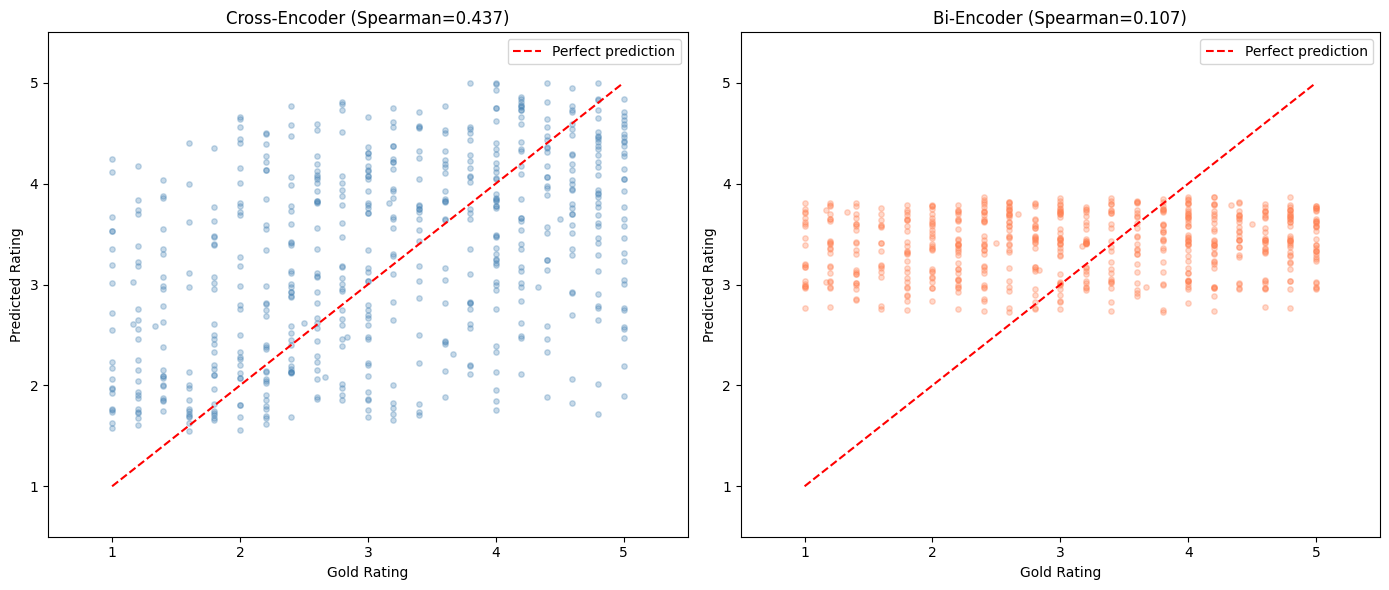

In [ ]:
#Predicted vs. Gold Scatterplots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(ce_gold, ce_preds, alpha=0.3, s=15, c='steelblue')
axes[0].plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
axes[0].set_title(f'Cross-Encoder (Spearman={ce_spearman:.3f})')
axes[0].set_xlabel('Gold Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()
axes[0].set_xlim(0.5, 5.5); axes[0].set_ylim(0.5, 5.5)

axes[1].scatter(be_gold, be_preds, alpha=0.3, s=15, c='coral')
axes[1].plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
axes[1].set_title(f'Bi-Encoder (Spearman={be_spearman:.3f})')
axes[1].set_xlabel('Gold Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()
axes[1].set_xlim(0.5, 5.5); axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'predicted_vs_gold.png'), dpi=150, bbox_inches='tight')
plt.show()

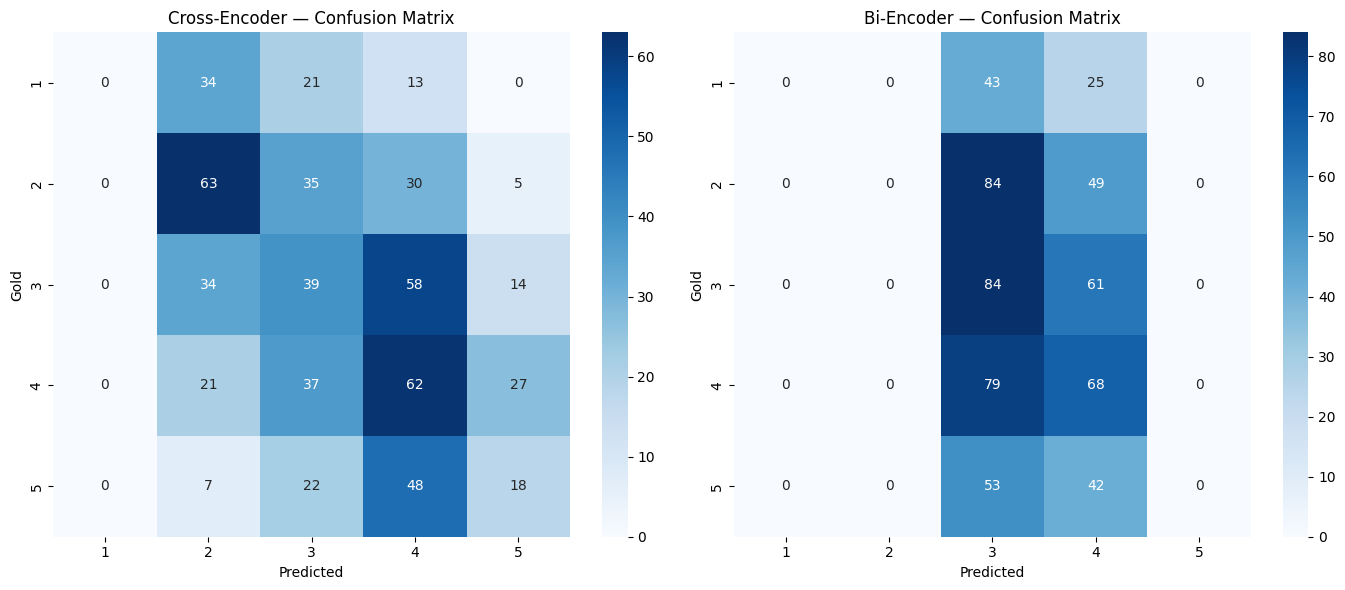

In [ ]:
#confusion matrix

def discretize_ratings(ratings):
  return np.clip(np.round(ratings), 1, 5).astype(int)

ce_preds_disc = discretize_ratings(ce_preds)
be_preds_disc = discretize_ratings(be_preds)
gold_disc = discretize_ratings(ce_gold)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title in [
    (axes[0], ce_preds_disc, 'Cross-Encoder'),
    (axes[1], be_preds_disc, 'Bi-Encoder')
]:
    cm = confusion_matrix(gold_disc, preds, labels=[1, 2, 3, 4, 5])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Gold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#f1, precision, recall

for name, preds_disc in [('Cross-Encoder', ce_preds_disc), ('Bi-Encoder', be_preds_disc)]:
    print(f"\n{name} Classification Report")
    print(classification_report(gold_disc, preds_disc, labels=[1,2,3,4,5], zero_division=0))
    macro_f1 = f1_score(gold_disc, preds_disc, average='macro', labels=[1,2,3,4,5], zero_division=0)
    macro_prec = precision_score(gold_disc, preds_disc, average='macro', labels=[1,2,3,4,5], zero_division=0)
    macro_rec = recall_score(gold_disc, preds_disc, average='macro', labels=[1,2,3,4,5], zero_division=0)
    print(f"Macro F1: {macro_f1:.4f}, Macro Precision: {macro_prec:.4f}, Macro Recall: {macro_rec:.4f}")


Cross-Encoder Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        68
           2       0.40      0.47      0.43       133
           3       0.25      0.27      0.26       145
           4       0.29      0.42      0.35       147
           5       0.28      0.19      0.23        95

    accuracy                           0.31       588
   macro avg       0.24      0.27      0.25       588
weighted avg       0.27      0.31      0.29       588

Macro F1: 0.2530, Macro Precision: 0.2449, Macro Recall: 0.2708

Bi-Encoder Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        68
           2       0.00      0.00      0.00       133
           3       0.24      0.58      0.34       145
           4       0.28      0.46      0.35       147
           5       0.00      0.00      0.00        95

    accuracy                           0.26       

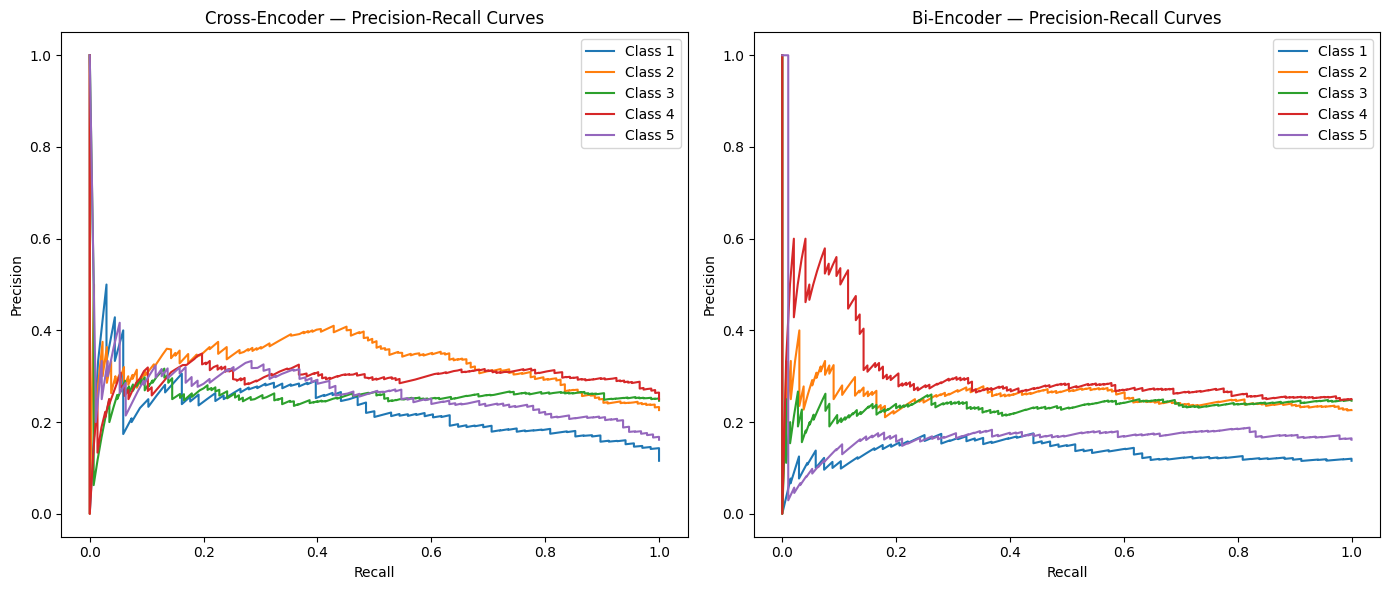

In [ ]:
#precision recall curves

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds_raw, title in [
    (axes[0], ce_preds, 'Cross-Encoder'),
    (axes[1], be_preds, 'Bi-Encoder')
]:
    for cls in [1, 2, 3, 4, 5]:
        y_true_binary = (gold_disc == cls).astype(int)
        y_scores = 1 - np.abs(preds_raw - cls) / 4.0
        precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
        ax.plot(recall, precision, label=f'Class {cls}')
    ax.set_title(f'{title} — Precision-Recall Curves')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'precision_recall_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

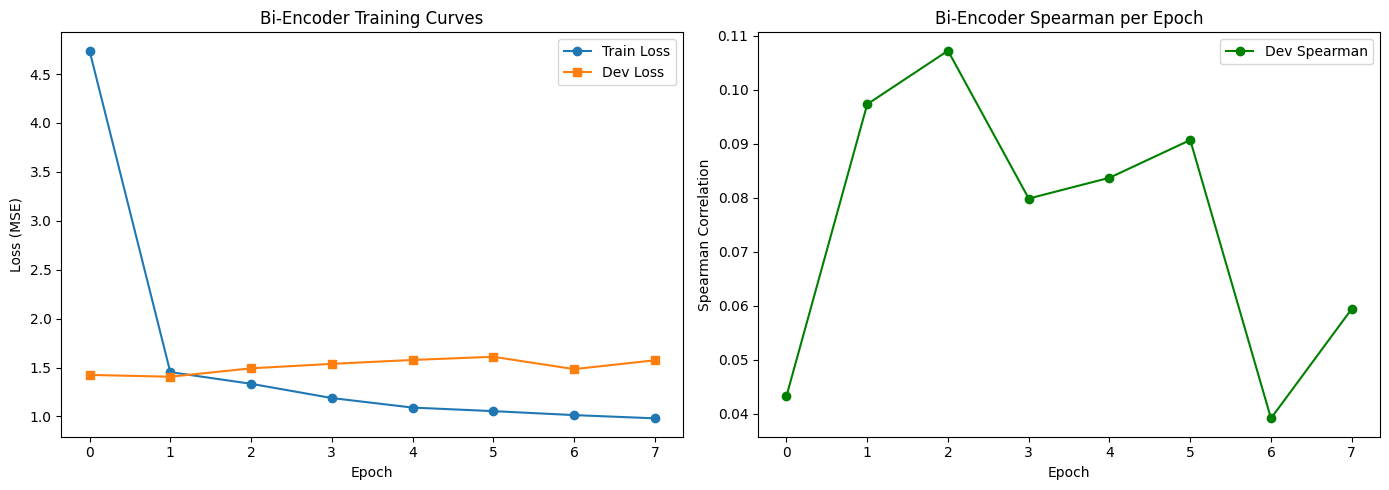

In [ ]:
#bi encoder training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(be_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(be_history['dev_loss'], label='Dev Loss', marker='s')
axes[0].set_title('Bi-Encoder Training Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

axes[1].plot(be_history['dev_spearman'], label='Dev Spearman', marker='o', color='green')
axes[1].set_title('Bi-Encoder Spearman per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Spearman Correlation')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bi_encoder_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

#Models evaluated on test set

In [ ]:
#cross encoder on test set
from torch.utils.data import DataLoader as TorchDataLoader

ce_model = trainer.model
ce_model.eval()

test_loader_ce = TorchDataLoader(test_dataset, batch_size=16)
ce_test_preds_list = []

with torch.no_grad():
    for batch in test_loader_ce:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = ce_model(input_ids=input_ids, attention_mask=attention_mask)
        ce_test_preds_list.extend(outputs.logits.squeeze(-1).cpu().numpy())

ce_test_preds = np.clip(np.array(ce_test_preds_list), 1.0, 5.0)
print(f"Cross-Encoder test predictions: {len(ce_test_preds)}")
print(f"Range: {ce_test_preds.min():.2f} - {ce_test_preds.max():.2f}")

Cross-Encoder test predictions: 930
Range: 1.59 - 4.83


In [ ]:
#bi encoder on test set
be_test_dataset = BiEncoderDataset(test_df, tokenizer)
test_loader = DataLoader(be_test_dataset, batch_size=16, shuffle=False)

be_model.eval()
be_test_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = be_model(**batch)
        be_test_preds_list.extend(outputs['logits'].cpu().numpy())

be_test_preds = np.clip(np.array(be_test_preds_list), 1.0, 5.0)
print(f"Bi-Encoder test predictions: {len(be_test_preds)}")
print(f"Range: {be_test_preds.min():.2f} - {be_test_preds.max():.2f}")

Bi-Encoder test predictions: 930
Range: 2.67 - 3.89


In [ ]:
test_preds_df = pd.DataFrame({
    'sample_id': test_df['sample_id'].values,
    'homonym': test_df['homonym'].values,
    'ce_prediction': ce_test_preds,
    'be_prediction': be_test_preds,
})
test_preds_df.to_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'), index=False)
print(f"Saved {len(test_preds_df)} test predictions to Drive")
print(test_preds_df.head(10))

Saved 930 test predictions to Drive
  sample_id homonym  ce_prediction  be_prediction
0      2017  levels       2.632812       2.853127
1      2018  levels       3.269531       3.809545
2      2019  levels       2.554688       2.872147
3      2020  levels       3.226562       3.829250
4      2021  levels       2.460938       2.863276
5      2022  levels       2.894531       3.819828
6      3127   level       2.541016       2.880920
7      3128   level       3.615234       3.836625
8      3129   level       2.574219       2.880324
9      3130   level       3.310547       3.836335


In [ ]:
final_results = pd.DataFrame({
    'Model': ['Cross-Encoder (BERT)', 'Bi-Encoder (BERT)'],
    'Dev Spearman': [ce_spearman, be_spearman],
    'Dev Accuracy@Std': [ce_acc_std, be_acc_std],
    'Dev MSE': [ce_mse, be_mse]
})
print(final_results.to_string(index=False))
final_results.to_csv(os.path.join(RESULTS_DIR, 'final_results.csv'), index=False)

               Model  Dev Spearman  Dev Accuracy@Std  Dev MSE
Cross-Encoder (BERT)      0.437390          0.568027 1.350580
   Bi-Encoder (BERT)      0.107253          0.517007 1.492062


## Error analysis

In [ ]:
dev_analysis = dev_df.copy()
dev_analysis['ce_pred'] = ce_preds
dev_analysis['be_pred'] = be_preds
dev_analysis['ce_error'] = np.abs(ce_preds - ce_gold)
dev_analysis['be_error'] = np.abs(be_preds - be_gold)

homonym_errors = dev_analysis.groupby('homonym').agg(
    ce_mean_error=('ce_error', 'mean'),
    be_mean_error=('be_error', 'mean'),
    count=('ce_error', 'count')
).sort_values('ce_mean_error', ascending=False)
print("Top 10 hardest homonyms ranked according to cross encoder error:")
print(homonym_errors.head(10).to_string())

Top 10 hardest homonyms ranked according to cross encoder error:
              ce_mean_error  be_mean_error  count
homonym                                          
coached            1.794336       0.860195      6
docked             1.627344       1.707834      6
tipped             1.562891       0.948950      6
rare               1.535970       0.826607     18
reservations       1.491254       1.099573     18
try                1.486719       1.608268      6
pick               1.426877       0.991146     18
blaze              1.380013       1.420714      6
tips               1.336046       1.189979     18
dribbled           1.328776       0.986045      6


/tmp/ipykernel_21152/1432086737.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = dev_analysis.groupby('rating_bin').agg(


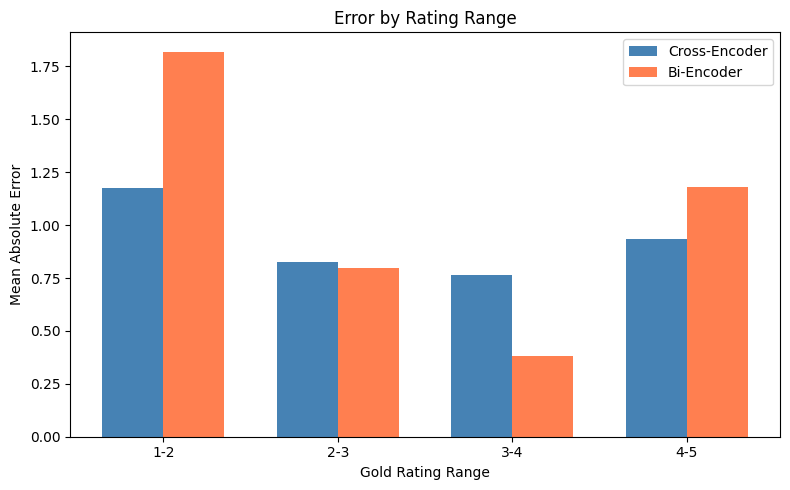

In [ ]:
dev_analysis['rating_bin'] = pd.cut(dev_analysis['average'],
                                     bins=[0, 2, 3, 4, 5],
                                     labels=['1-2', '2-3', '3-4', '4-5'])
error_by_bin = dev_analysis.groupby('rating_bin').agg(
    ce_mean_error=('ce_error', 'mean'),
    be_mean_error=('be_error', 'mean'),
    count=('ce_error', 'count')
)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(error_by_bin))
width = 0.35
ax.bar(x - width/2, error_by_bin['ce_mean_error'], width, label='Cross-Encoder', color='steelblue')
ax.bar(x + width/2, error_by_bin['be_mean_error'], width, label='Bi-Encoder', color='coral')
ax.set_xlabel('Gold Rating Range')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Error by Rating Range')
ax.set_xticks(x)
ax.set_xticklabels(error_by_bin.index)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'error_by_rating_range.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#5 worst predictions
worst_ce = dev_analysis.nlargest(5, 'ce_error')
print("5 Worst Predictions according to cross encoder error")
for _, row in worst_ce.iterrows():
    print(f"\nHomonym: {row['homonym']}")
    print(f"Meaning: {row['judged_meaning']}")
    print(f"Gold: {row['average']}, Predicted: {row['ce_pred']:.2f}, Error: {row['ce_error']:.2f}")
    print(f"Story: {row['story'][:150]}")

5 Worst Predictions according to cross encoder error

Homonym: tips
Meaning: a relatively small amount of money given for services rendered (as by a waiter)
Gold: 1.0, Predicted: 4.25, Error: 3.25
Story: John had just moved to the city and was trying out the neighborhood's restaurants. That evening, he decided to visit a small Italian place around the 

Homonym: docked
Meaning: come into dock
Gold: 1.0, Predicted: 4.12, Error: 3.12
Story: Sean had always dreamt of working by the sea. His job at the harbor kept him busy, overseeing shipments and coordinating arrivals. Yesterday, a hiccup

Homonym: pick
Meaning: pull lightly but sharply with a plucking motion
Gold: 5.0, Predicted: 1.90, Error: 3.10
Story: Emma walked through the orchard with a basket in her hand. The trees were full of ripe, red apples, and she hesitated for a moment. Her mother had tol

Homonym: point
Meaning: the object of an activity
Gold: 4.8, Predicted: 1.72, Error: 3.08
Story: Jack was nervous about the camping tri

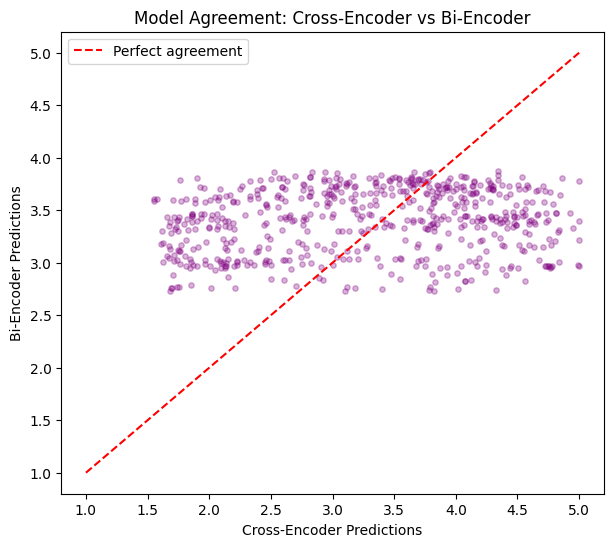

Spearman: 0.1435


In [ ]:
#model agreement
plt.figure(figsize=(7, 6))
plt.scatter(ce_preds, be_preds, alpha=0.3, s=15, c='purple')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect agreement')
plt.xlabel('Cross-Encoder Predictions')
plt.ylabel('Bi-Encoder Predictions')
plt.title('Model Agreement: Cross-Encoder vs Bi-Encoder')
plt.legend()
plt.savefig(os.path.join(PLOTS_DIR, 'model_agreement.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Spearman: {spearmanr(ce_preds, be_preds).correlation:.4f}")

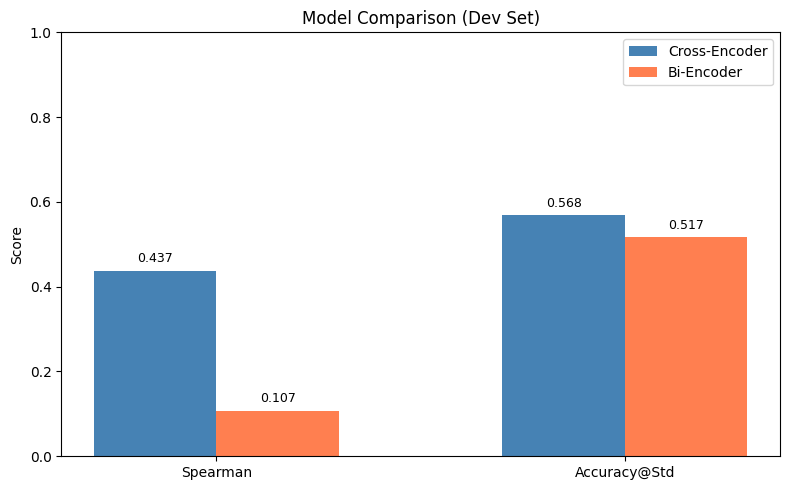

In [ ]:
#bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Spearman', 'Accuracy@Std']
ce_vals = [ce_spearman, ce_acc_std]
be_vals = [be_spearman, be_acc_std]
x = np.arange(len(metrics))
width = 0.3
ax.bar(x - width/2, ce_vals, width, label='Cross-Encoder', color='steelblue')
ax.bar(x + width/2, be_vals, width, label='Bi-Encoder', color='coral')
ax.set_ylabel('Score')
ax.set_title('Model Comparison (Dev Set)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
for i, (cv, bv) in enumerate(zip(ce_vals, be_vals)):
    ax.text(i - width/2, cv + 0.02, f'{cv:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, bv + 0.02, f'{bv:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#save predictions
dev_analysis.to_csv(os.path.join(RESULTS_DIR, 'dev_predictions.csv'), index=False)

print(f"\n outputs saved to: {SHARED_FOLDER}")
for root, dirs, files in os.walk(SHARED_FOLDER):
    level = root.replace(SHARED_FOLDER, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{'  ' * (level + 1)}{f}")


 outputs saved to: /content/drive/MyDrive/CS445 Group Project
CS445 Group Project/
  dataset setup.ipynb
  models/
    cross_encoder/
      config.json
      model.safetensors
      training_args.bin
      tokenizer_config.json
      tokenizer.json
    bi_encoder/
      bi_encoder_best.pt
      training_history.json
  plots/
    confusion_matrices.png
    predicted_vs_gold.png
    precision_recall_curves.png
    bi_encoder_training_curves.png
    error_by_rating_range.png
    model_agreement.png
    model_comparison_bar.png
    ce_gold_vs_prediction.png
    ce_prediction_distribution.png
  results/
    test_predictions.csv
    final_results.csv
    dev_predictions.csv
    ce_metrics.json
    cross_encoder_results.csv
  results 1.0 - saved aside for now/
    cross_encoder_results.csv
